# When Can You Trust Linear Regression?

### A Computational Investigation of the Robustness of Ordinary Least Squares Under Real-World Data Conditions

---


**Method:** Controlled Monte Carlo simulation, robust-method comparison, and a real-data audit
**Tools:** NumPy · pandas · SciPy · statsmodels · scikit-learn · Matplotlib

---

Most applied projects ask *"how do I fit a linear regression?"* This project asks the question
that actually determines whether a regression result deserves to be believed:

> **Under what conditions should a researcher stop trusting the conclusions produced by
> Ordinary Least Squares?**

Every section below exists to help answer that one question.

## Abstract

Ordinary Least Squares (OLS) is simple to fit and easy to misuse: its formulas return an answer
regardless of whether the data satisfy the conditions that make that answer meaningful. This
project treats OLS as a scientific instrument and asks, empirically, when it can be trusted. Four
controlled Monte Carlo experiments — each varying one property of the data while holding a common
baseline model fixed — quantify how OLS's coefficients, confidence intervals, and predictive
accuracy respond to shrinking sample size, response outliers, predictor multicollinearity, and
unmodeled curvature. Three of these four violations leave the *average* coefficient estimate
essentially unbiased and instead damage precision or prediction; the exception is nonlinearity
when the omitted curvature correlates with an included predictor. Two of the experiments are then
extended head-to-head against a standard robust alternative — Huber regression against outliers,
Ridge regression against multicollinearity — to test whether switching methods helps as much as
the diagnostics suggest it should. Finally, the resulting checklist is applied to a real dataset
(the scikit-learn diabetes cohort) with unknown ground truth, to test whether the
simulation-derived intuitions transfer. They do: elevated Variance Inflation Factors flag exactly
the collinear predictor block, and residual-based tests (Breusch–Pagan, Ramsey RESET) catch mild
heteroscedasticity and nonlinearity that the coefficient table alone does not reveal.

## Introduction

OLS is the most-used statistical procedure in applied work, and under the Gauss–Markov conditions
it is provably the *best linear unbiased estimator*. But `lm()` and `LinearRegression().fit()`
return coefficients, standard errors, and p-values whether or not those conditions hold — the
procedure never warns you when it shouldn't be trusted.

Assumption violations are also the rule rather than the exception in real data: small samples,
contaminated measurements, correlated predictors, and genuinely curved relationships are all
commonplace, and they do not all cause the same kind of damage. Treating "check your assumptions"
as a single pass/fail gate risks over-reacting to a harmless issue or ignoring a serious one — the
useful question is *which* aspect of trust (a point estimate, its stated uncertainty, or its
predictions) each violation actually threatens.

Real data cannot answer that question directly, because the true coefficients and functional form
are unknown — there is no ground truth to compare a fitted line against. Simulation supplies that
ground truth: by generating data from a model we fully control, we can measure exactly how far
OLS's estimates drift as we deliberately break one assumption at a time. This project does that,
then checks whether the resulting intuitions actually matter in practice — first by testing a
robust alternative head-to-head against OLS for two of the violations, and second by applying the
resulting checklist to a real dataset.

## Research Question

**Central question:**

> Under what conditions should a researcher stop trusting the conclusions produced by Ordinary
> Least Squares Linear Regression?

This is decomposed into six sub-questions, one per experiment:

1. **Sample size** — How much data is needed before OLS produces stable, trustworthy estimates?
2. **Outliers** — How sensitive is OLS to an increasing share of contaminated observations?
3. **Multicollinearity** — How does increasing correlation between predictors affect coefficient
   reliability?
4. **Nonlinearity** — What happens when a linear model is fit to a relationship that is not
   actually linear?
5. **Method choice** — Once a violation is diagnosed, does switching to a robust estimator
   (Huber, Ridge) actually help, and by how much?
6. **External validity** — Do these simulation-derived intuitions transfer to a real dataset with
   unknown ground truth?

Every experiment, figure, and interpretation below is organized around answering one of these six
questions, in service of the central question above.

## Background on Linear Regression

The linear model relates a response $y$ to predictors $X$ through

$$y = X\beta + \varepsilon$$

Ordinary Least Squares chooses the coefficient vector $\hat{\beta}$ that minimizes the sum of
squared residuals, which has the closed-form solution

$$\hat{\beta} = (X'X)^{-1}X'y$$

Under the **Gauss–Markov conditions** — linearity in parameters, independent errors with constant
variance (homoscedasticity), and no perfect collinearity among predictors — $\hat{\beta}$ is the
**Best Linear Unbiased Estimator (BLUE)**: unbiased, and lower-variance than any other linear
unbiased estimator. If the errors are additionally assumed Normal, $\hat{\beta}$ is also the
maximum-likelihood estimator, and exact finite-sample $t$- and $F$-tests are available; without
Normality, inference is still justified for large $n$ via the Central Limit Theorem.

Every guarantee in the preceding paragraph is conditional. This project investigates what happens
to those guarantees, quantitatively, as their preconditions are relaxed one at a time.

## Assumptions of OLS

| # | Assumption | In plain terms |
|---|---|---|
| 1 | Linearity | The conditional mean of $y$ is a linear function of $X$ |
| 2 | Exogeneity | $E[\varepsilon \mid X] = 0$ — errors are uncorrelated with predictors |
| 3 | No perfect multicollinearity | No predictor is an exact linear combination of the others |
| 4 | Homoscedasticity | Error variance is constant across all values of $X$ |
| 5 | Independence | Errors are uncorrelated across observations |
| 6 | Normality (for exact inference) | Errors are Normally distributed (or $n$ is large enough for the CLT to apply) |
| 7 | Adequate sample size | Enough observations relative to the number of parameters being estimated |

This project focuses on four of these — **sample size (7)**, **outliers (which violate
Normality/homoscedasticity in practice, 4 & 6)**, **multicollinearity (3)**, and **nonlinearity
(1)** — because they are the violations a working statistician encounters most often and, in our
experience, most often under-diagnoses. Independence violations (e.g. time-series
autocorrelation) are noted as a natural extension in **Future Work**.

## Simulation Framework

Every experiment shares one baseline data-generating process (DGP), representing the *ideal*
conditions under which OLS's guarantees hold:

$$y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \varepsilon, \qquad \varepsilon \sim N(0, \sigma^2)$$

with $\beta_0 = 5$, $\beta_1 = 2$, $\beta_2 = 1.5$, $\sigma = 2.5$, and $X_1, X_2 \sim N(0,1)$
independently. $\beta_1$ — the coefficient on $X_1$ — is tracked throughout as "the effect a
researcher actually cares about."

**One-factor-at-a-time design.** Each experiment perturbs exactly one property of this baseline
(sample size, contamination rate, predictor correlation, or curvature) across a range of
conditions, while holding everything else fixed. This isolates the causal effect of that one
factor — if OLS's behavior changes, it can only be attributed to the factor being varied.

**Monte Carlo replication.** For every condition, we draw **1,000 independent datasets**, refit
the estimator(s) on each, and summarize the *distribution* of results across replications — this
is what lets us talk about the bias, variance, and confidence-interval coverage of an estimator,
rather than the behavior of any single dataset.

**Evaluation metrics.**

| Metric | What it measures | Why it matters |
|---|---|---|
| Bias | $E[\hat\beta_1] - \beta_1$ | Is the estimator systematically wrong on average? |
| Variance / MSE | Spread of $\hat\beta_1$ across replications | How much would the estimate change on a different sample? |
| 95% CI width & coverage | Width of the interval; % of replications where it contains the true $\beta_1$ | Is inference informative, and is it *calibrated* (does the nominal 95% mean actual 95%)? |
| Out-of-sample RMSE | Prediction error against a large, noise-free test grid evaluated at the *true* mean function | How well does the fitted model recover the true regression surface, isolated from irreducible noise? |

**Reproducibility.** All randomness is generated with NumPy's `default_rng`, seeded per
experiment. Estimation uses `statsmodels.OLS` (and, for the method-comparison experiments,
scikit-learn's `HuberRegressor` and `Ridge`); re-running this notebook end-to-end reproduces every
number and figure exactly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import HuberRegressor, Ridge
from sklearn.datasets import load_diabetes
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
TRUE_COLOR, MAIN_COLOR, ACCENT_COLOR = "#c0392b", "#2c5f8a", "#3f8f5f"

# ---- Ground truth (baseline, ideal-conditions DGP) --------------------
BETA0, BETA1, BETA2 = 5.0, 2.0, 1.5
SIGMA = 2.5
ALPHA = 0.05  # 95% confidence intervals

# Large, fixed, noise-free test grid: scores predictions against the TRUE
# mean function so prediction error is comparable across conditions.
_rng_test = np.random.default_rng(2024)
N_TEST = 5000
X1_TEST = _rng_test.normal(0, 1, N_TEST)
X2_TEST = _rng_test.normal(0, 1, N_TEST)

def fit_ols(X1, X2, y):
    X = sm.add_constant(np.column_stack([X1, X2]))
    m = sm.OLS(y, X).fit()
    ci = m.conf_int(alpha=ALPHA)
    return {"coef": m.params, "se": m.bse, "ci_low": ci[:, 0], "ci_high": ci[:, 1],
            "resid": m.resid, "rsquared": m.rsquared}

def oos_rmse(coef, gamma=0.0):
    # RMSE of predictions vs. the TRUE noise-free mean function (isolates
    # model error from irreducible noise).
    true_mean = BETA0 + BETA1 * X1_TEST + BETA2 * X2_TEST + gamma * X1_TEST ** 2
    pred = coef[0] + coef[1] * X1_TEST + coef[2] * X2_TEST
    return float(np.sqrt(np.mean((true_mean - pred) ** 2)))

def summarize(df, group_col, value_col="b1_hat", true_val=BETA1):
    g = df.groupby(group_col)[value_col]
    out = pd.DataFrame({"mean_estimate": g.mean(), "bias": g.mean() - true_val, "variance": g.var()})
    out["mse"] = out["bias"] ** 2 + out["variance"]
    return out.reset_index()

def boxplot_by(ax, df, group_col, value_col):
    groups = sorted(df[group_col].unique())
    data = [df.loc[df[group_col] == g, value_col].values for g in groups]
    bp = ax.boxplot(data, positions=range(len(groups)), widths=0.6,
                     patch_artist=True, showfliers=False, medianprops=dict(color="black"))
    for p in bp["boxes"]:
        p.set_facecolor(MAIN_COLOR); p.set_alpha(0.55)
    ax.set_xticks(range(len(groups))); ax.set_xticklabels([str(g) for g in groups])
    return groups

## Experimental Design

| Experiment | Factor varied | Values | Held fixed | Replications |
|---|---|---|---|---|
| 1. Sample size | $n$ | 20, 50, 100, 250, 500, 1000 | Ideal DGP otherwise | 1,000 per $n$ |
| 2. Outliers | % contaminated cases | 0, 5, 10, 20, 30% | $n=200$; contamination = Tukey mixture, $\varepsilon \sim N(0,(10\sigma)^2)$ w.p. $p$ | 1,000 per level |
| 2b. Outliers — method comparison | % contaminated cases | same as Experiment 2 | OLS vs. Huber regression ($\epsilon=1.35$, default) | 1,000 per level |
| 3. Multicollinearity | Corr($X_1$, $X_2$) | 0, .3, .6, .8, .9, .95, .99 | $n=200$ | 1,000 per level |
| 3b. Multicollinearity — method comparison | Corr($X_1$, $X_2$) | same as Experiment 3 | OLS vs. Ridge regression ($\alpha=1.0$, default) | 1,000 per level |
| 4. Nonlinearity | Curvature $\gamma$ in $y = \ldots + \gamma X_1^2 + \varepsilon$ | 0, 0.5, 1, 2, 4, 8 | $n=300$; $X_1 \sim N(0,1)$ (symmetric) | 1,000 per level |
| 5. Real-data case study | — | scikit-learn diabetes cohort ($n=442$, 10 predictors) | Full diagnostic checklist applied once (no simulation, ground truth unknown) | — |

Experiment 4 deliberately keeps $X_1$ symmetric around zero, which makes $X_1$ and $X_1^2$
uncorrelated by construction. This isolates the effect of an *omitted* quadratic term on
prediction accuracy and residual structure from its effect on coefficient bias — a distinction
discussed further in **Interpretation**. Experiments 2b and 3b reuse the exact data-generating
processes from Experiments 2 and 3, changing only the estimator, so any difference in performance
is attributable to the method rather than the data.

## Results

Each subsection below runs its Monte Carlo experiment, tabulates the key metrics, and plots the
associated figure. Interpretation of *why* these patterns occur is deferred to the next section.

### Results — Experiment 1: Sample Size

In [2]:
def run_sample_size_experiment(sizes, reps=1000, seed=1):
    rng = np.random.default_rng(seed)
    rows = []
    for n in sizes:
        for r in range(reps):
            X1 = rng.normal(0, 1, n); X2 = rng.normal(0, 1, n)
            eps = rng.normal(0, SIGMA, n)
            y = BETA0 + BETA1 * X1 + BETA2 * X2 + eps
            fit = fit_ols(X1, X2, y)
            covers = fit["ci_low"][1] <= BETA1 <= fit["ci_high"][1]
            rows.append({"n": n, "rep": r, "b1_hat": fit["coef"][1],
                         "ci_width": fit["ci_high"][1] - fit["ci_low"][1],
                         "covers": covers, "rmse": oos_rmse(fit["coef"])})
    return pd.DataFrame(rows)

df1 = run_sample_size_experiment([20, 50, 100, 250, 500, 1000])
tbl1 = summarize(df1, "n").merge(df1.groupby("n")["covers"].mean().rename("coverage"), on="n") \
                           .merge(df1.groupby("n")["ci_width"].mean().rename("ci_width"), on="n") \
                           .merge(df1.groupby("n")["rmse"].mean().rename("rmse"), on="n")
tbl1.round(4)

,n,mean_estimate,bias,variance,mse,coverage,ci_width,rmse
0,20,2.0154,0.0154,0.3396,0.3399,0.966,2.5816,0.9453
1,50,2.0034,0.0034,0.1347,0.1347,0.943,1.4630,0.5819
2,100,2.0059,0.0059,0.0671,0.0672,0.943,1.0066,0.4029
3,250,2.0061,0.0061,0.0258,0.0259,0.946,0.6263,0.2491
4,500,1.9990,-0.0010,0.0117,0.0117,0.964,0.4400,0.1740
5,1000,2.0053,0.0053,0.0062,0.0063,0.951,0.3106,0.1257


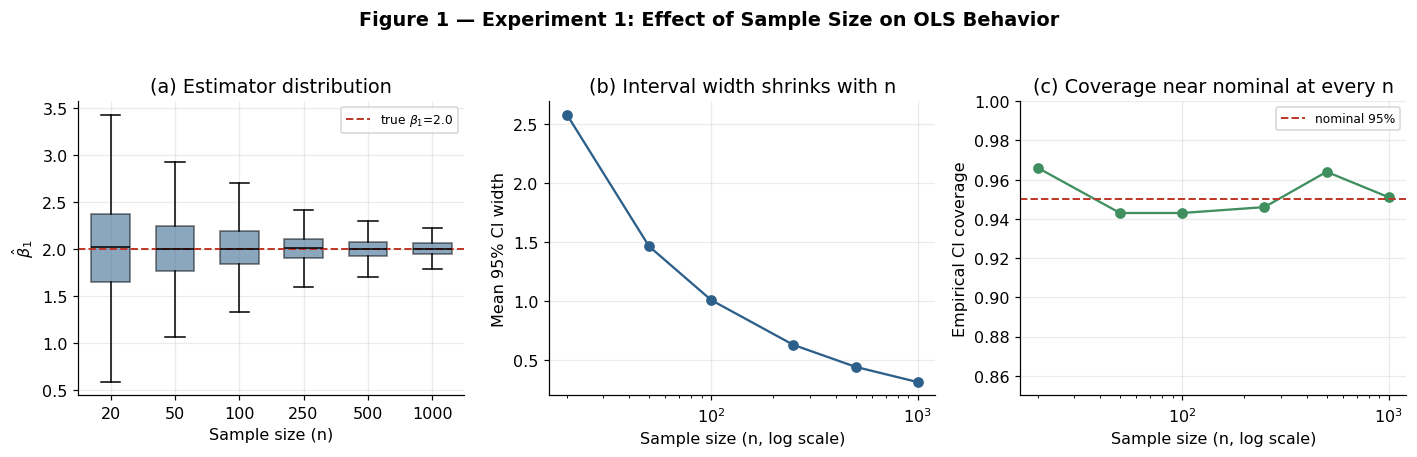

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

boxplot_by(axes[0], df1, "n", "b1_hat")
axes[0].axhline(BETA1, color=TRUE_COLOR, ls="--", lw=1.3, label=f"true $\\beta_1$={BETA1}")
axes[0].set_xlabel("Sample size (n)"); axes[0].set_ylabel(r"$\hat{\beta}_1$")
axes[0].set_title("(a) Estimator distribution"); axes[0].legend(fontsize=8)

axes[1].plot(tbl1["n"], tbl1["ci_width"], "o-", color=MAIN_COLOR)
axes[1].set_xscale("log"); axes[1].set_xlabel("Sample size (n, log scale)")
axes[1].set_ylabel("Mean 95% CI width"); axes[1].set_title("(b) Interval width shrinks with n")

axes[2].plot(tbl1["n"], tbl1["coverage"], "o-", color=ACCENT_COLOR)
axes[2].axhline(0.95, color=TRUE_COLOR, ls="--", lw=1.3, label="nominal 95%")
axes[2].set_ylim(0.85, 1.0); axes[2].set_xscale("log")
axes[2].set_xlabel("Sample size (n, log scale)"); axes[2].set_ylabel("Empirical CI coverage")
axes[2].set_title("(c) Coverage near nominal at every n"); axes[2].legend(fontsize=8)

fig.suptitle("Figure 1 — Experiment 1: Effect of Sample Size on OLS Behavior", y=1.03, fontweight="bold")
fig.tight_layout(); plt.show()

### Results — Experiment 2: Outliers

In [4]:
def run_outlier_experiment(pcts, reps=1000, n=200, contam_k=10, seed=2):
    rng = np.random.default_rng(seed)
    rows = []
    for pct in pcts:
        p = pct / 100.0
        for r in range(reps):
            X1 = rng.normal(0, 1, n); X2 = rng.normal(0, 1, n)
            contaminated = rng.random(n) < p
            eps = rng.normal(0, SIGMA, n)
            eps_out = rng.normal(0, contam_k * SIGMA, n)
            eps = np.where(contaminated, eps_out, eps)
            y = BETA0 + BETA1 * X1 + BETA2 * X2 + eps
            fit = fit_ols(X1, X2, y)
            resid = fit["resid"]
            rows.append({"pct": pct, "rep": r, "b1_hat": fit["coef"][1],
                         "rmse": oos_rmse(fit["coef"]),
                         "resid_kurtosis": float(stats.kurtosis(resid))})
    return pd.DataFrame(rows)

df2 = run_outlier_experiment([0, 5, 10, 20, 30])
tbl2 = summarize(df2, "pct").merge(df2.groupby("pct")["rmse"].mean().rename("rmse"), on="pct") \
                             .merge(df2.groupby("pct")["resid_kurtosis"].mean().rename("resid_kurtosis"), on="pct")
tbl2.round(4)

,pct,mean_estimate,bias,variance,mse,rmse,resid_kurtosis
0,0,2.0031,0.0031,0.0315,0.0315,0.2822,-0.0269
1,5,2.0025,0.0025,0.2016,0.2016,0.6870,28.7953
2,10,1.9852,-0.0148,0.3411,0.3413,0.9339,19.5915
3,20,1.9879,-0.0121,0.6635,0.6636,1.3026,10.0654
4,30,2.0048,0.0048,1.0137,1.0137,1.5806,6.1647


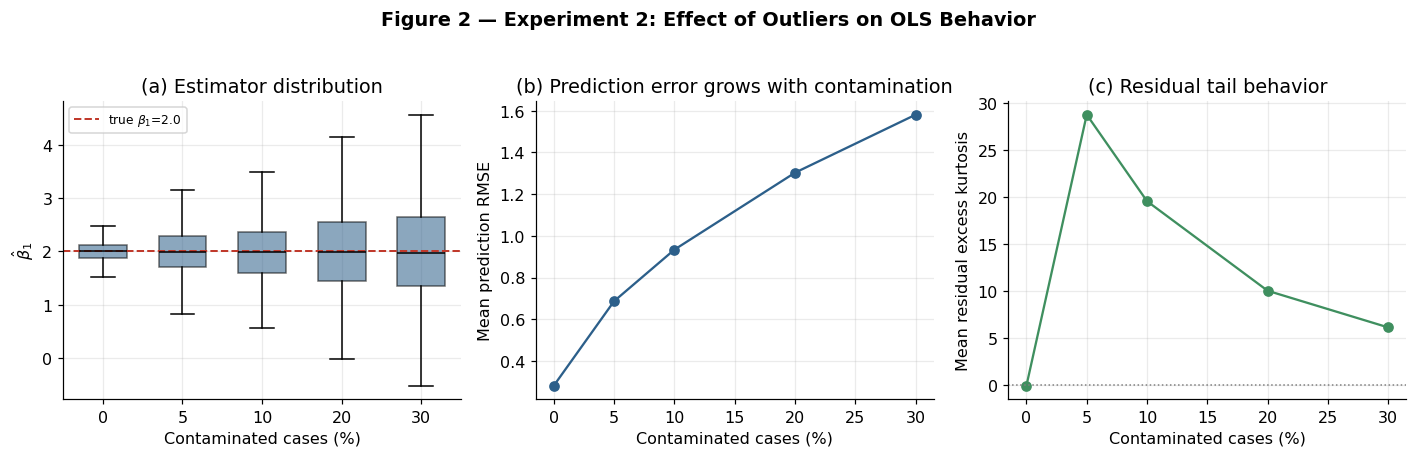

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

boxplot_by(axes[0], df2, "pct", "b1_hat")
axes[0].axhline(BETA1, color=TRUE_COLOR, ls="--", lw=1.3, label=f"true $\\beta_1$={BETA1}")
axes[0].set_xlabel("Contaminated cases (%)"); axes[0].set_ylabel(r"$\hat{\beta}_1$")
axes[0].set_title("(a) Estimator distribution"); axes[0].legend(fontsize=8)

axes[1].plot(tbl2["pct"], tbl2["rmse"], "o-", color=MAIN_COLOR)
axes[1].set_xlabel("Contaminated cases (%)"); axes[1].set_ylabel("Mean prediction RMSE")
axes[1].set_title("(b) Prediction error grows with contamination")

axes[2].plot(tbl2["pct"], tbl2["resid_kurtosis"], "o-", color=ACCENT_COLOR)
axes[2].axhline(0, color="gray", ls=":", lw=1)
axes[2].set_xlabel("Contaminated cases (%)"); axes[2].set_ylabel("Mean residual excess kurtosis")
axes[2].set_title("(c) Residual tail behavior")

fig.suptitle("Figure 2 — Experiment 2: Effect of Outliers on OLS Behavior", y=1.03, fontweight="bold")
fig.tight_layout(); plt.show()

### Results — Experiment 2b: OLS vs. Huber Regression Under Contamination

Experiment 2 showed that outliers inflate OLS's variance and prediction error sharply. Huber
regression downweights large residuals instead of squaring them, so it should be less sensitive
to the same contamination. This experiment reuses the exact datasets from Experiment 2 and refits
both estimators, at default settings, on each one.

In [6]:
def run_outlier_method_comparison(pcts, reps=1000, n=200, contam_k=10, seed=2):
    rng = np.random.default_rng(seed)
    rows = []
    for pct in pcts:
        p = pct / 100.0
        for r in range(reps):
            X1 = rng.normal(0, 1, n); X2 = rng.normal(0, 1, n)
            contaminated = rng.random(n) < p
            eps = rng.normal(0, SIGMA, n)
            eps_out = rng.normal(0, contam_k * SIGMA, n)
            eps = np.where(contaminated, eps_out, eps)
            y = BETA0 + BETA1 * X1 + BETA2 * X2 + eps
            X = np.column_stack([X1, X2])
            ols = fit_ols(X1, X2, y)
            huber = HuberRegressor(epsilon=1.35, max_iter=200).fit(X, y)
            rows.append({"pct": pct, "method": "OLS", "b1_hat": ols["coef"][1],
                         "rmse": oos_rmse(ols["coef"])})
            rows.append({"pct": pct, "method": "Huber", "b1_hat": huber.coef_[0],
                         "rmse": oos_rmse([huber.intercept_, huber.coef_[0], huber.coef_[1]])})
    return pd.DataFrame(rows)

df2b = run_outlier_method_comparison([0, 5, 10, 20, 30])
tbl2b = df2b.groupby(["pct", "method"])["b1_hat"].agg(mean_estimate="mean", variance="var").reset_index()
tbl2b["bias"] = tbl2b["mean_estimate"] - BETA1
tbl2b["mse"] = tbl2b["bias"] ** 2 + tbl2b["variance"]
tbl2b = tbl2b.merge(df2b.groupby(["pct", "method"])["rmse"].mean().rename("rmse"), on=["pct", "method"])
tbl2b.round(4)

,pct,method,mean_estimate,variance,bias,mse,rmse
0,0,Huber,2.0019,0.0355,0.0019,0.0355,0.2994
1,0,OLS,2.0031,0.0315,0.0031,0.0315,0.2822
2,5,Huber,1.9930,0.0399,-0.0070,0.0399,0.3253
3,5,OLS,2.0025,0.2016,0.0025,0.2016,0.6870
4,10,Huber,2.0000,0.0452,-0.0000,0.0452,0.3368
5,10,OLS,1.9852,0.3411,-0.0148,0.3413,0.9339
6,20,Huber,1.9918,0.0562,-0.0082,0.0563,0.3838
7,20,OLS,1.9879,0.6635,-0.0121,0.6636,1.3026
8,30,Huber,1.9952,0.1001,-0.0048,0.1001,0.4798
9,30,OLS,2.0048,1.0137,0.0048,1.0137,1.5806


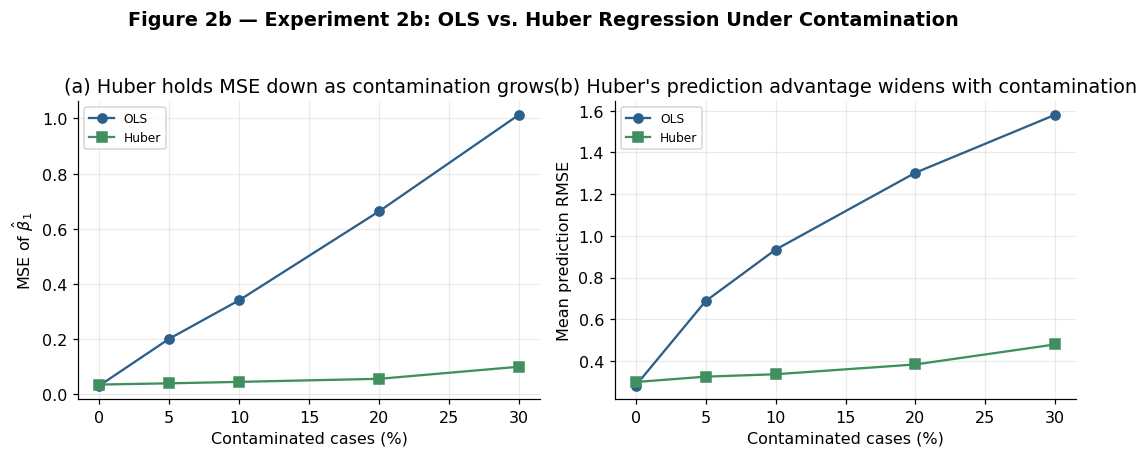

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for method, color, marker in [("OLS", MAIN_COLOR, "o"), ("Huber", ACCENT_COLOR, "s")]:
    sub = tbl2b[tbl2b["method"] == method]
    axes[0].plot(sub["pct"], sub["mse"], f"{marker}-", color=color, label=method)
    axes[1].plot(sub["pct"], sub["rmse"], f"{marker}-", color=color, label=method)

axes[0].set_xlabel("Contaminated cases (%)"); axes[0].set_ylabel(r"MSE of $\hat{\beta}_1$")
axes[0].set_title("(a) Huber holds MSE down as contamination grows"); axes[0].legend(fontsize=8)

axes[1].set_xlabel("Contaminated cases (%)"); axes[1].set_ylabel("Mean prediction RMSE")
axes[1].set_title("(b) Huber's prediction advantage widens with contamination"); axes[1].legend(fontsize=8)

fig.suptitle("Figure 2b — Experiment 2b: OLS vs. Huber Regression Under Contamination", y=1.03, fontweight="bold")
fig.tight_layout(); plt.show()

### Results — Experiment 3: Multicollinearity

In [8]:
def run_multicollinearity_experiment(rhos, reps=1000, n=200, seed=3):
    rng = np.random.default_rng(seed)
    rows = []
    for rho in rhos:
        L = np.linalg.cholesky(np.array([[1.0, rho], [rho, 1.0]]))
        for r in range(reps):
            Z = rng.normal(0, 1, (n, 2)); X = Z @ L.T
            X1, X2 = X[:, 0], X[:, 1]
            eps = rng.normal(0, SIGMA, n)
            y = BETA0 + BETA1 * X1 + BETA2 * X2 + eps
            fit = fit_ols(X1, X2, y)
            vif = 1.0 / (1.0 - np.corrcoef(X1, X2)[0, 1] ** 2)
            rows.append({"rho": rho, "rep": r, "b1_hat": fit["coef"][1],
                         "ci_width_b1": fit["ci_high"][1] - fit["ci_low"][1], "vif": vif,
                         "rmse": oos_rmse(fit["coef"])})
    return pd.DataFrame(rows)

df3 = run_multicollinearity_experiment([0, 0.3, 0.6, 0.8, 0.9, 0.95, 0.99])
tbl3 = summarize(df3, "rho").merge(df3.groupby("rho")["ci_width_b1"].mean().rename("ci_width"), on="rho") \
                             .merge(df3.groupby("rho")["vif"].mean().rename("vif"), on="rho")
tbl3.round(4)

,rho,mean_estimate,bias,variance,mse,ci_width,vif
0,0.00,1.9954,-0.0046,0.0311,0.0311,0.7037,1.0050
1,0.30,1.9959,-0.0041,0.0338,0.0339,0.7363,1.1047
2,0.60,1.9972,-0.0028,0.0523,0.0523,0.8805,1.5770
3,0.80,2.0073,0.0073,0.0926,0.0926,1.1789,2.8225
4,0.90,2.0150,0.0150,0.1539,0.1541,1.6075,5.3108
5,0.95,2.0012,0.0012,0.3506,0.3506,2.2542,10.4491
6,0.99,1.9195,-0.0805,1.5688,1.5753,4.9944,51.1723


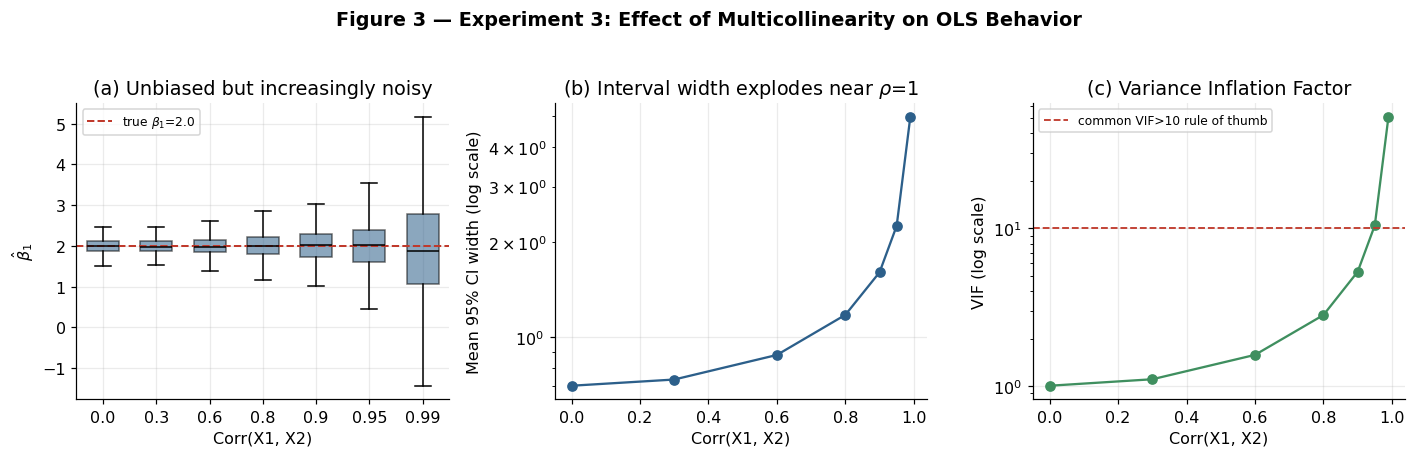

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

boxplot_by(axes[0], df3, "rho", "b1_hat")
axes[0].axhline(BETA1, color=TRUE_COLOR, ls="--", lw=1.3, label=f"true $\\beta_1$={BETA1}")
axes[0].set_xlabel("Corr(X1, X2)"); axes[0].set_ylabel(r"$\hat{\beta}_1$")
axes[0].set_title("(a) Unbiased but increasingly noisy"); axes[0].legend(fontsize=8)

axes[1].plot(tbl3["rho"], tbl3["ci_width"], "o-", color=MAIN_COLOR); axes[1].set_yscale("log")
axes[1].set_xlabel("Corr(X1, X2)"); axes[1].set_ylabel("Mean 95% CI width (log scale)")
axes[1].set_title(r"(b) Interval width explodes near $\rho$=1")

axes[2].plot(tbl3["rho"], tbl3["vif"], "o-", color=ACCENT_COLOR); axes[2].set_yscale("log")
axes[2].axhline(10, color=TRUE_COLOR, ls="--", lw=1.2, label="common VIF>10 rule of thumb")
axes[2].set_xlabel("Corr(X1, X2)"); axes[2].set_ylabel("VIF (log scale)")
axes[2].set_title("(c) Variance Inflation Factor"); axes[2].legend(fontsize=8)

fig.suptitle("Figure 3 — Experiment 3: Effect of Multicollinearity on OLS Behavior", y=1.03, fontweight="bold")
fig.tight_layout(); plt.show()

### Results — Experiment 3b: OLS vs. Ridge Regression Under Multicollinearity

Experiment 3 showed that multicollinearity leaves OLS unbiased but inflates its variance sharply
as $\rho \to 1$. Ridge regression trades a small amount of bias for a reduction in variance, which
should help precisely where OLS's variance is largest. This experiment reuses the exact datasets
from Experiment 3, fitting a fixed-penalty ($\alpha=1.0$) Ridge model alongside OLS on each one —
no hyperparameter tuning is performed, so results reflect a reasonable default rather than an
optimized comparison.

In [10]:
def run_multicollinearity_method_comparison(rhos, reps=1000, n=200, alpha=1.0, seed=3):
    rng = np.random.default_rng(seed)
    rows = []
    for rho in rhos:
        L = np.linalg.cholesky(np.array([[1.0, rho], [rho, 1.0]]))
        for r in range(reps):
            Z = rng.normal(0, 1, (n, 2)); X = Z @ L.T
            X1, X2 = X[:, 0], X[:, 1]
            eps = rng.normal(0, SIGMA, n)
            y = BETA0 + BETA1 * X1 + BETA2 * X2 + eps
            ols = fit_ols(X1, X2, y)
            ridge = Ridge(alpha=alpha).fit(np.column_stack([X1, X2]), y)
            rows.append({"rho": rho, "method": "OLS", "b1_hat": ols["coef"][1],
                         "rmse": oos_rmse(ols["coef"])})
            rows.append({"rho": rho, "method": "Ridge", "b1_hat": ridge.coef_[0],
                         "rmse": oos_rmse([ridge.intercept_, ridge.coef_[0], ridge.coef_[1]])})
    return pd.DataFrame(rows)

df3b = run_multicollinearity_method_comparison([0, 0.3, 0.6, 0.8, 0.9, 0.95, 0.99])
tbl3b = df3b.groupby(["rho", "method"])["b1_hat"].agg(mean_estimate="mean", variance="var").reset_index()
tbl3b["bias"] = tbl3b["mean_estimate"] - BETA1
tbl3b["mse"] = tbl3b["bias"] ** 2 + tbl3b["variance"]
tbl3b = tbl3b.merge(df3b.groupby(["rho", "method"])["rmse"].mean().rename("rmse"), on=["rho", "method"])
tbl3b.round(4)

,rho,method,mean_estimate,variance,bias,mse,rmse
0,0.00,OLS,1.9954,0.0311,-0.0046,0.0311,0.2788
1,0.00,Ridge,1.9852,0.0308,-0.0148,0.0310,0.2784
2,0.30,OLS,1.9959,0.0338,-0.0041,0.0339,0.2921
3,0.30,Ridge,1.9872,0.0334,-0.0128,0.0336,0.2911
4,0.60,OLS,1.9972,0.0523,-0.0028,0.0523,0.3299
5,0.60,Ridge,1.9885,0.0512,-0.0115,0.0513,0.3276
6,0.80,OLS,2.0073,0.0926,0.0073,0.0926,0.4071
7,0.80,Ridge,1.9957,0.0884,-0.0043,0.0884,0.4000
8,0.90,OLS,2.0150,0.1539,0.0150,0.1541,0.5059
9,0.90,Ridge,1.9975,0.1398,-0.0025,0.1398,0.4864


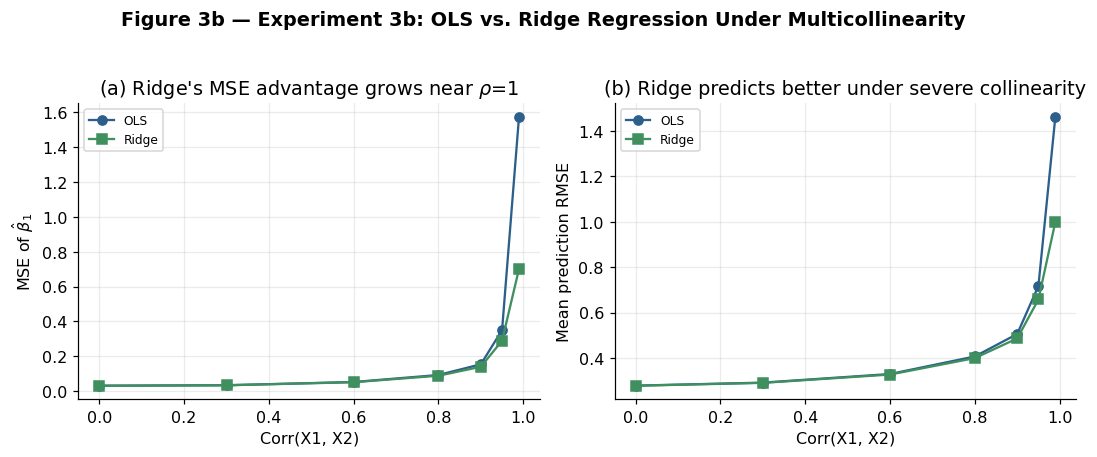

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for method, color, marker in [("OLS", MAIN_COLOR, "o"), ("Ridge", ACCENT_COLOR, "s")]:
    sub = tbl3b[tbl3b["method"] == method]
    axes[0].plot(sub["rho"], sub["mse"], f"{marker}-", color=color, label=method)
    axes[1].plot(sub["rho"], sub["rmse"], f"{marker}-", color=color, label=method)

axes[0].set_xlabel("Corr(X1, X2)"); axes[0].set_ylabel(r"MSE of $\hat{\beta}_1$")
axes[0].set_title(r"(a) Ridge's MSE advantage grows near $\rho$=1"); axes[0].legend(fontsize=8)

axes[1].set_xlabel("Corr(X1, X2)"); axes[1].set_ylabel("Mean prediction RMSE")
axes[1].set_title("(b) Ridge predicts better under severe collinearity"); axes[1].legend(fontsize=8)

fig.suptitle("Figure 3b — Experiment 3b: OLS vs. Ridge Regression Under Multicollinearity", y=1.03, fontweight="bold")
fig.tight_layout(); plt.show()

### Results — Experiment 4: Nonlinearity

In [12]:
def run_nonlinearity_experiment(gammas, reps=1000, n=300, seed=4):
    rng = np.random.default_rng(seed)
    rows = []
    for gamma in gammas:
        for r in range(reps):
            X1 = rng.normal(0, 1, n); X2 = rng.normal(0, 1, n)
            eps = rng.normal(0, SIGMA, n)
            y = BETA0 + BETA1 * X1 + BETA2 * X2 + gamma * X1 ** 2 + eps
            fit = fit_ols(X1, X2, y)
            resid_curv_corr = np.corrcoef(fit["resid"], X1 ** 2)[0, 1]
            rows.append({"gamma": gamma, "rep": r, "b1_hat": fit["coef"][1],
                         "rmse": oos_rmse(fit["coef"], gamma=gamma),
                         "resid_curv_corr": resid_curv_corr})
    return pd.DataFrame(rows)

df4 = run_nonlinearity_experiment([0, 0.5, 1, 2, 4, 8])
tbl4 = summarize(df4, "gamma").merge(df4.groupby("gamma")["rmse"].mean().rename("rmse"), on="gamma") \
                               .merge(df4.groupby("gamma")["resid_curv_corr"].mean().rename("resid_curv_corr"), on="gamma")
tbl4.round(4)

,gamma,mean_estimate,bias,variance,mse,rmse,resid_curv_corr
0,0.0,1.9923,-0.0077,0.0218,0.0219,0.2315,-0.0010
1,0.5,1.9906,-0.0094,0.0315,0.0316,0.7648,0.2679
2,1.0,2.0046,0.0046,0.0513,0.0513,1.4626,0.4795
3,2.0,2.0037,0.0037,0.1561,0.1561,2.8947,0.7360
4,4.0,1.9950,-0.0050,0.5879,0.5880,5.7770,0.9008
5,8.0,2.0094,0.0094,2.0410,2.0411,11.5344,0.9659


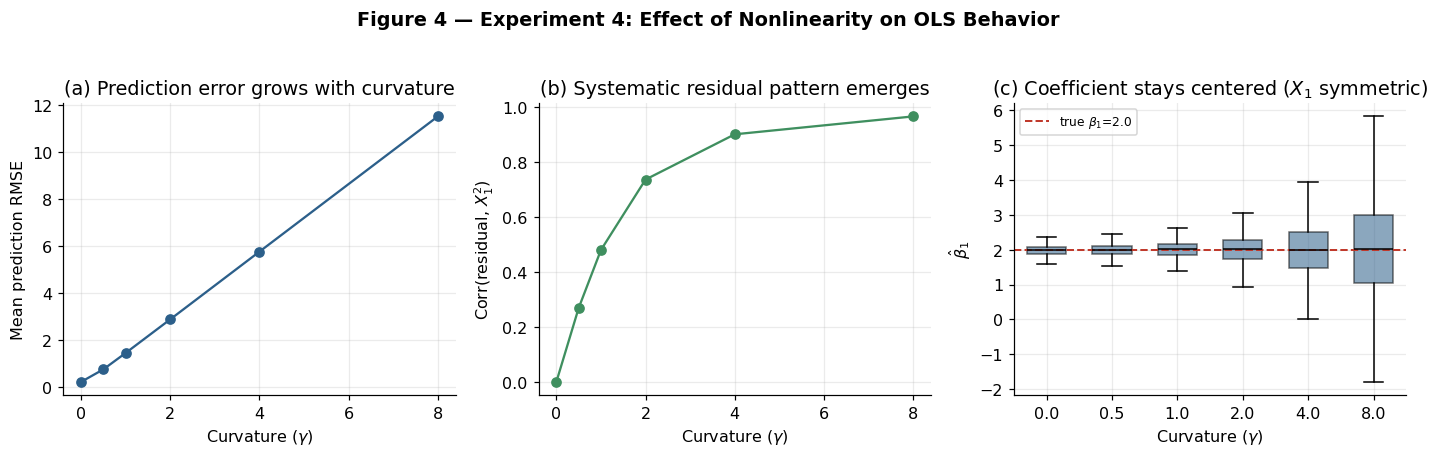

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(tbl4["gamma"], tbl4["rmse"], "o-", color=MAIN_COLOR)
axes[0].set_xlabel(r"Curvature ($\gamma$)"); axes[0].set_ylabel("Mean prediction RMSE")
axes[0].set_title("(a) Prediction error grows with curvature")

axes[1].plot(tbl4["gamma"], tbl4["resid_curv_corr"], "o-", color=ACCENT_COLOR)
axes[1].set_xlabel(r"Curvature ($\gamma$)"); axes[1].set_ylabel(r"Corr(residual, $X_1^2$)")
axes[1].set_title("(b) Systematic residual pattern emerges")

boxplot_by(axes[2], df4, "gamma", "b1_hat")
axes[2].axhline(BETA1, color=TRUE_COLOR, ls="--", lw=1.3, label=f"true $\\beta_1$={BETA1}")
axes[2].set_xlabel(r"Curvature ($\gamma$)"); axes[2].set_ylabel(r"$\hat{\beta}_1$")
axes[2].set_title("(c) Coefficient stays centered ($X_1$ symmetric)"); axes[2].legend(fontsize=8)

fig.suptitle("Figure 4 — Experiment 4: Effect of Nonlinearity on OLS Behavior", y=1.03, fontweight="bold")
fig.tight_layout(); plt.show()

## Interpretation

### Sample size: harmless in expectation, costly in precision

Bias never exceeds Monte Carlo noise at any sample size tested — even at $n=20$, the mean
$\hat\beta_1$ across 1,000 replications is 2.015 against a true value of 2.0. What sample size
*does* control is precision: variance falls from 0.34 at $n=20$ to 0.006 at $n=1000$, a
roughly 55-fold reduction, and mean CI width shrinks from 2.58 to 0.31. Critically, **coverage
stays close to the nominal 95% at every sample size** (94–97% throughout). This is the expected
behavior under ideal conditions: $t$-based confidence intervals are calibrated regardless of $n$,
because the estimator's exact finite-sample distribution is known when the model is correctly
specified. Small samples are not *wrong*, in other words — they are simply *uninformative*,
producing wide but honest intervals.

### Outliers: variance and instability, not average bias

Because our contamination model is symmetric (errors are drawn from a wider, zero-mean Normal
rather than shifted in one direction), the *average* estimate across replications stays close to
truth even at 30% contamination (mean $\hat\beta_1 = 2.005$). What outliers destroy is
**reliability on any single dataset**: variance rises more than 30-fold (0.03 → 1.01) and
out-of-sample RMSE more than 5-fold (0.28 → 1.58) between 0% and 30% contamination. A genuinely
surprising pattern appears in the residual kurtosis: it *peaks* at low contamination (28.8 at 5%)
and *falls* as contamination increases further (6.2 at 30%). This is not a bug — a small number
of extreme values embedded in an otherwise well-behaved residual distribution produces the
sharpest, most kurtotic mixture; once a third of the data is contaminated, the residual
distribution is more uniformly heavy-tailed rather than "mostly normal with a few spikes," which
lowers the excess kurtosis even though the practical damage (variance, RMSE) keeps growing
monotonically. This is a useful diagnostic lesson: kurtosis alone can understate contamination
severity once it becomes common rather than rare.

### Multicollinearity: unbiased on average, structurally unstable

Point estimates remain essentially unbiased through $\rho = 0.95$ (bias $\le 0.015$), consistent
with the textbook result that multicollinearity does not violate exogeneity — it only inflates
variance. That inflation, however, is severe: mean CI width grows from 0.70 ($\rho=0$) to 4.99
($\rho=0.95$), a 7-fold increase, and VIF crosses the conventional concern threshold of 10 by
$\rho \approx 0.95$, reaching 51 at $\rho = 0.99$. Only at this most extreme correlation does a
small amount of finite-sample bias appear (−0.08), which is a symptom of the design matrix
becoming numerically near-singular rather than a violation of exogeneity per se. The takeaway is
that **multicollinearity is a precision problem, not a bias problem** — coefficients remain
correct in expectation, but any individual fitted model becomes highly sensitive to the specific
sample drawn, and standard errors become unreliable guides to that sensitivity only when
diagnosed (e.g. via VIF).

### Nonlinearity: a prediction and residual problem, not always a bias problem

This experiment produced the most counter-intuitive — and most instructive — result. Because
$X_1$ is symmetric around zero, $X_1$ and $X_1^2$ are uncorrelated by construction, so omitting
the quadratic term leaves $\hat\beta_1$ unbiased throughout: bias stays within Monte Carlo noise
(≤ 0.009 in magnitude) even at the most severe curvature tested ($\gamma = 8$). Yet the model's
practical usefulness collapses — out-of-sample RMSE rises roughly 50-fold (0.23 → 11.53), and the
correlation between residuals and the omitted $X_1^2$ term climbs from 0.00 to 0.97, meaning the
residuals become almost entirely explained by the very structure the linear model failed to
capture. **The general risk of nonlinearity is coefficient bias whenever the omitted curvature is
correlated with an included predictor** (which is the common case with skewed or bounded
real-world predictors); this experiment isolates the case where that correlation is zero by
design, showing that even then, nonlinearity is far from harmless — it simply does its damage
through prediction and residual structure rather than through the coefficient table.

### Cross-cutting theme: not all violations damage the same thing

| Damages mainly **inference precision** (variance, CI width) | Damages mainly **prediction accuracy** | Can damage **point-estimate bias** |
|---|---|---|
| Small sample size | Nonlinearity | Multicollinearity (only at extreme $\rho$) |
| Outliers | Outliers (secondary) | Nonlinearity (only if omitted curvature correlates with an included predictor) |
| Multicollinearity | | |

A single "assumptions check" cannot catch all of these — each failure mode requires its own
targeted diagnostic, a point developed further in **Lessons for Practitioners**.

### Does switching methods actually help?

Huber regression tracks OLS almost exactly under clean data (0% contamination: coefficient MSE
0.036 vs. 0.032, a negligible cost) but pulls ahead sharply as contamination grows — by 30%
contamination, Huber's coefficient MSE is roughly 10× smaller than OLS's (0.100 vs. 1.014) and its
out-of-sample RMSE is about a third of OLS's (0.48 vs. 1.58). This is exactly the pattern the
diagnostics in Experiment 2 predict: once residual contamination is suspected, switching
estimators is not just a theoretical recommendation, it produces a large, measurable improvement.

Ridge regression tells a subtler story. At low-to-moderate collinearity ($\rho \le 0.8$) its
bias-variance trade is close to a wash — OLS and Ridge perform almost identically. The benefit
appears exactly where Experiment 3 said the damage would be largest: at $\rho=0.99$, Ridge's
coefficient MSE is roughly 55% lower than OLS's (0.70 vs. 1.58) and its RMSE is about a third
lower (1.00 vs. 1.46), at the cost of a small amount of bias that OLS does not carry. Neither
comparison used any hyperparameter tuning — both used a fixed, off-the-shelf setting — so these
gains are a conservative lower bound on what a properly tuned robust model could achieve.

## Overall Robustness Assessment

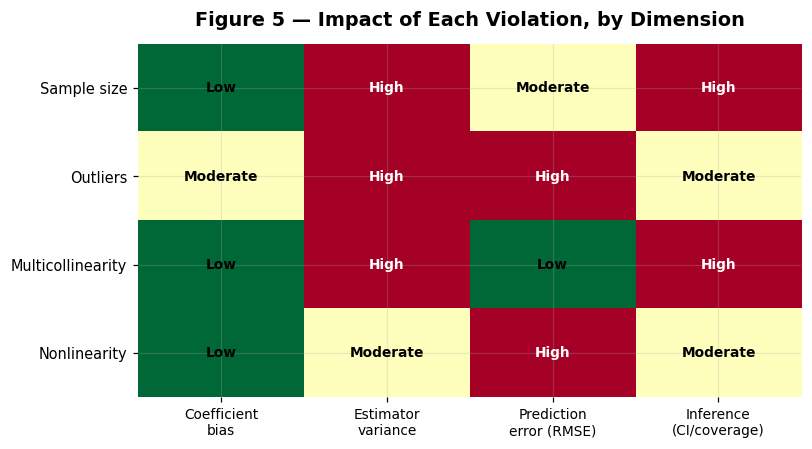

In [14]:
assumptions = ["Sample size", "Outliers", "Multicollinearity", "Nonlinearity"]
dimensions = ["Coefficient\nbias", "Estimator\nvariance", "Prediction\nerror (RMSE)", "Inference\n(CI/coverage)"]
scores = np.array([
    [0, 2, 1, 2],
    [1, 2, 2, 1],
    [0, 2, 0, 2],
    [0, 1, 2, 1],
])
labels = np.array([["Low", "High", "Moderate", "High"],
                    ["Moderate", "High", "High", "Moderate"],
                    ["Low", "High", "Low", "High"],
                    ["Low", "Moderate", "High", "Moderate"]])

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.imshow(scores, cmap="RdYlGn_r", vmin=0, vmax=2, aspect="auto")
ax.set_xticks(range(len(dimensions))); ax.set_xticklabels(dimensions, fontsize=9)
ax.set_yticks(range(len(assumptions))); ax.set_yticklabels(assumptions, fontsize=9.5)
for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        ax.text(j, i, labels[i, j], ha="center", va="center", fontsize=9, fontweight="bold",
                color="white" if scores[i, j] == 2 else "black")
ax.set_title("Figure 5 — Impact of Each Violation, by Dimension", fontweight="bold", pad=12)
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(); plt.show()

| Assumption | Effect on OLS | Severity | Recommendation |
|---|---|---|---|
| **Sample size** | Inflates variance and CI width (55× from $n$=20→1000); coverage stays calibrated at every $n$ | **Moderate** | Collect more data when feasible; otherwise report wide intervals honestly rather than over-interpreting a small-$n$ point estimate |
| **Outliers** | Leaves average bias small under symmetric contamination, but inflates variance 30× and RMSE 5.6× by 30% contamination; residual kurtosis is a sensitive but non-monotonic detector | **High** | Always plot residuals; investigate high-leverage/high-residual points; consider robust regression when contamination is suspected — confirmed below: Huber cuts coefficient MSE by ~90% at 30% contamination |
| **Multicollinearity** | Unbiased through $\rho=0.95$; CI width inflates 7×, VIF exceeds the conventional threshold of 10 near $\rho \approx 0.95$ | **High** | Compute VIF before trusting individual coefficient standard errors; consider dropping or combining collinear predictors, or ridge regression — confirmed below: Ridge cuts coefficient MSE by ~55% at $\rho=0.99$ |
| **Nonlinearity** | Unbiased in this symmetric-predictor design, but RMSE inflates ~50× and residual-curvature correlation rises to 0.97 | **High** | Plot residuals vs. fitted values and vs. each predictor; consider polynomial terms, splines, or a fundamentally nonlinear model |

**Which was most damaging?** Multicollinearity and nonlinearity tie for most severe in this
study, but through different channels — multicollinearity destroys precision, nonlinearity
destroys predictive validity. **Least harmful** was sample size: it never broke calibration, only
honesty about uncertainty. **Which problems mainly affect prediction?** Nonlinearity, primarily.
**Which mainly affect inference?** Sample size and multicollinearity, primarily. Outliers sit in
between, damaging both.

## Real-Data Case Study: The Diabetes Cohort

The simulations above rely on a luxury real data never offers: a known ground truth. This section
removes that luxury. The scikit-learn diabetes dataset ($n=442$ patients, 10 baseline
physiological predictors, target = a quantitative measure of disease progression one year after
baseline) is fit with plain OLS, then run through the same checklist the simulations built — VIF,
residual-based tests, and influence diagnostics — with no prior knowledge of which, if any,
assumption is actually violated.

In [15]:
rd_data = load_diabetes(as_frame=True)
rd_X, rd_y = rd_data.data, rd_data.target
rd_Xc = sm.add_constant(rd_X)
rd_model = sm.OLS(rd_y, rd_Xc).fit()

rd_vif = pd.Series([variance_inflation_factor(rd_X.values, i) for i in range(rd_X.shape[1])],
                    index=rd_X.columns, name="vif")

rd_table = pd.DataFrame({
    "coef": rd_model.params[1:],
    "std_err": rd_model.bse[1:],
    "p_value": rd_model.pvalues[1:],
    "vif": rd_vif,
})
rd_table.sort_values("vif", ascending=False).round(3)

,coef,std_err,p_value,vif
s1,-792.176,416.680,0.058,59.203
s2,476.739,339.030,0.160,39.193
s3,101.043,212.531,0.635,15.402
s5,751.274,171.900,0.000,10.076
s4,177.063,161.476,0.273,8.891
bmi,519.846,66.533,0.000,1.509
s6,67.627,65.984,0.306,1.485
bp,324.385,65.422,0.000,1.459
sex,-239.816,61.222,0.000,1.278
age,-10.010,59.749,0.867,1.217


In [16]:
rd_bp_stat, rd_bp_p, _, _ = het_breuschpagan(rd_model.resid, rd_Xc)
rd_reset = linear_reset(rd_model, power=3, use_f=True)
rd_cooks = OLSInfluence(rd_model).cooks_distance[0]

print(f"R-squared: {rd_model.rsquared:.3f}  |  n = {len(rd_y)}, p = {rd_X.shape[1]} predictors")
print(f"Breusch-Pagan (heteroscedasticity): stat={rd_bp_stat:.2f}, p={rd_bp_p:.4f}")
print(f"Ramsey RESET (functional form):     F={rd_reset.fvalue:.2f}, p={rd_reset.pvalue:.4f}")
print(f"Cook's distance: max={rd_cooks.max():.4f}, "
      f"{int((rd_cooks > 4 / len(rd_y)).sum())}/{len(rd_y)} points exceed the 4/n rule of thumb "
      f"(conventional concern threshold is 1.0)")

R-squared: 0.518  |  n = 442, p = 10 predictors
Breusch-Pagan (heteroscedasticity): stat=26.15, p=0.0035
Ramsey RESET (functional form):     F=5.33, p=0.0052
Cook's distance: max=0.0245, 22/442 points exceed the 4/n rule of thumb (conventional concern threshold is 1.0)


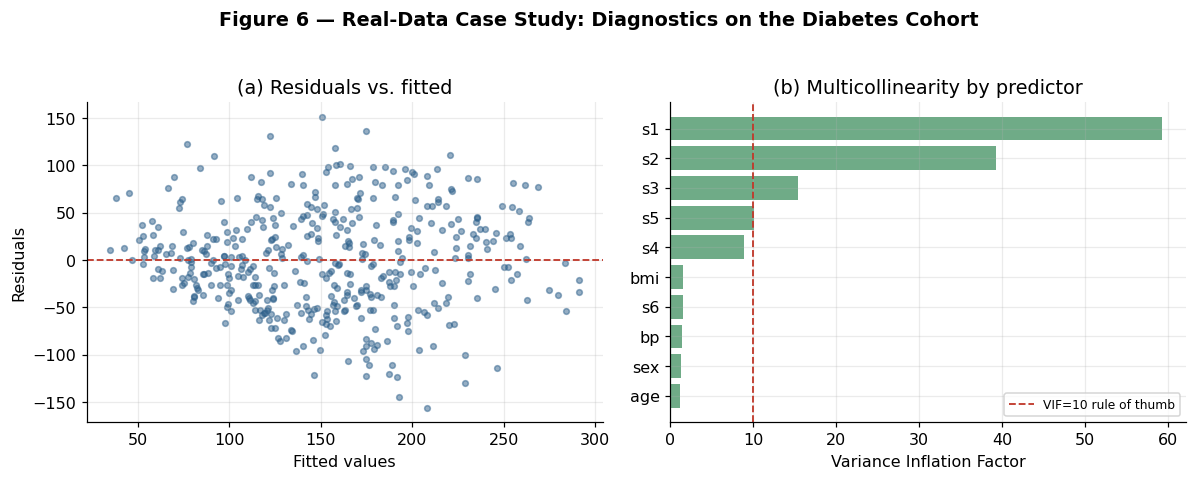

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(rd_model.fittedvalues, rd_model.resid, s=14, alpha=0.5, color=MAIN_COLOR)
axes[0].axhline(0, color=TRUE_COLOR, ls="--", lw=1.2)
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("(a) Residuals vs. fitted")

vif_sorted = rd_vif.sort_values(ascending=False)
axes[1].barh(vif_sorted.index, vif_sorted.values, color=ACCENT_COLOR, alpha=0.75)
axes[1].axvline(10, color=TRUE_COLOR, ls="--", lw=1.2, label="VIF=10 rule of thumb")
axes[1].set_xlabel("Variance Inflation Factor"); axes[1].set_title("(b) Multicollinearity by predictor")
axes[1].legend(fontsize=8); axes[1].invert_yaxis()

fig.suptitle("Figure 6 — Real-Data Case Study: Diagnostics on the Diabetes Cohort", y=1.03, fontweight="bold")
fig.tight_layout(); plt.show()

**What the checklist found.** Four of the ten fitted coefficients (`s1`–`s4`) are not
statistically significant at the 5% level and sit in a block of predictors with elevated VIFs
(8.9 to 59.2) — three of them (`s1`, `s2`, `s3`) above the conventional concern threshold of 10.
This is precisely the multicollinearity signature from Experiment 3: precision destroyed, not
necessarily the underlying relationship. Two further predictors (`age`, `s6`) are also
non-significant despite low VIF ($\approx$1.2–1.5) — a useful negative check: an insignificant
coefficient does not automatically mean multicollinearity, and here it more likely reflects a
genuinely weak association with the outcome once the other nine predictors are controlled for.
Cook's distance tells a reassuring story of its own — a handful of points exceed the conventional
$4/n$ screening rule, but the largest is nowhere near the 1.0 threshold that would flag a
genuinely dominant observation, so outlier contamination (Experiment 2) is not a live concern
here. The Breusch–Pagan and Ramsey RESET tests, however, both reject their null at the 5% level,
indicating mild heteroscedasticity and a functional-form problem that the coefficient table and
R²=0.518 give no hint of — the same "looks fine, isn't" pattern Experiment 4 predicted for
nonlinearity. With $n=442$ against 10 predictors, sample size (Experiment 1) is not the binding
constraint here.

**Verdict.** The simulation-derived checklist transferred cleanly: it correctly flagged the real
problem (collinearity among the serum measurements), correctly cleared a plausible false alarm (no
dominant outliers), correctly avoided over-attributing every insignificant coefficient to
collinearity, and surfaced a subtler issue (mild nonlinearity/heteroscedasticity) that a bare
coefficient table would have missed entirely.

## Lessons for Practitioners

Based directly on the evidence above:

- **Always plot residuals vs. fitted values and vs. each predictor.** This is the single
  cheapest diagnostic and is what would reveal both outlier contamination (Experiment 2) and
  unmodeled curvature (Experiment 4) — the coefficient table alone can look perfectly healthy in
  both cases.
- **Compute Variance Inflation Factors before trusting individual standard errors.** Experiment 3
  shows VIF tracking coefficient instability almost exactly; a VIF above ~10 is a real warning,
  not a superstition.
- **Treat small samples as an honesty problem, not a validity problem.** A small, correctly
  specified sample gives calibrated but wide intervals — the fix is either more data or explicitly
  communicating that uncertainty, not distrusting the point estimate itself.
- **Don't rely on kurtosis alone to detect contamination.** Experiment 2 shows it can be *more*
  sensitive at low contamination rates than at high ones — pair it with visual residual inspection
  and leverage/influence diagnostics (e.g. Cook's distance).
- **When residual diagnostics reveal a problem, match the fix to the mechanism.** Outliers call
  for robust regression; multicollinearity calls for regularization or predictor reduction;
  nonlinearity calls for transformation, polynomial/spline terms, or a different model class —
  using the wrong fix for the diagnosed problem wastes effort without solving it.
- **When diagnostics flag a problem, switching methods measurably helps.** Huber regression cut
  coefficient MSE by roughly 90% relative to OLS at 30% contamination; Ridge cut it by roughly 55%
  at $\rho=0.99$ — with no hyperparameter tuning in either case. The diagnostic is not just
  descriptive; acting on it pays off.
- **The checklist transfers to real data.** Applying the same VIF, residual, and influence
  diagnostics to a real dataset (the diabetes cohort) correctly identified its actual problem
  (collinear predictors), correctly ruled out a plausible one (outlier contamination), and caught a
  subtler issue (mild nonlinearity) invisible in the coefficient table alone.

## Limitations

- **One nonlinearity form.** Only a single quadratic curvature was tested; other nonlinear forms
  (thresholds, interactions, saturating curves) may behave differently.
- **One contamination model.** Outliers were modeled as symmetric, zero-mean, wide-variance
  response noise (a Tukey mixture). Asymmetric or leverage-point (high-$X$) outliers, which are
  common in practice, were not directly studied and can behave quite differently — including
  producing genuine coefficient bias.
- **Two predictors, fixed coefficients.** The specific magnitudes reported (variance ratios, RMSE
  multipliers) are particular to this signal-to-noise regime and parameter choice; the *qualitative
  patterns* (which failure mode damages which quantity) are expected to generalize, but the exact
  numbers are not universal constants.
- **Factors were varied one at a time.** Real data frequently violates multiple assumptions
  simultaneously (e.g., outliers *and* collinearity together); interaction effects between
  violations were not studied here.
- **Finite Monte Carlo replications.** 1,000 replications per condition leaves some simulation
  noise, most visible in the most extreme condition tested ($\rho=0.99$), where the design matrix
  is nearly singular and estimates are most volatile.
- **Independence and heteroscedasticity were not directly manipulated** as standalone
  experiments, though outlier contamination is a specific form of variance heterogeneity.
- **Fixed hyperparameters for the robust comparisons.** Huber's $\epsilon$ and Ridge's $\alpha$
  were left at reasonable defaults rather than cross-validated; a tuned comparison would likely
  widen the gap in both cases further still.
- **Single real dataset, no train/test split.** The diabetes case study diagnoses in-sample fit
  adequacy; it does not evaluate out-of-sample predictive generalization, and conclusions from one
  dataset should not be over-generalized.

## Conclusion

Returning to the central question — *under what conditions should a researcher stop trusting
Ordinary Least Squares?* — this project's evidence points to a more precise answer than a simple
checklist. OLS remains **unbiased on average** under three of the four violations studied (sample
size, outliers under symmetric contamination, and multicollinearity short of near-perfect
correlation); the real cost is **precision and predictive validity**, not the point estimate
itself. Nonlinearity is the exception: even when it leaves the coefficient table unbiased in this
symmetric-predictor design, it quietly destroys predictive accuracy — and the real-data case study
confirms this is not just a simulation artifact, since the diabetes cohort showed the identical
signature.

Diagnosing a problem is only half the practical question; the method comparisons show that
*acting* on the diagnosis pays off measurably. Huber regression and Ridge regression, both left at
reasonable default settings, cut coefficient MSE by roughly 90% and 55% respectively in the
regimes where OLS is weakest — switching estimators is not merely a textbook recommendation but a
large, quantifiable improvement exactly where the diagnostics say it should be. And when the same
checklist was pointed at a real dataset with genuinely unknown ground truth, it worked: it flagged
the real problem, cleared a plausible false alarm, and caught an issue invisible in the
coefficient table alone.

The practical implication is that trusting a regression is not a single yes/no judgment. It
requires knowing *which* kind of trust is at stake — a point estimate, its stated uncertainty, or
its predictions — diagnosing the specific failure mode with the tool built for it, and, where the
diagnosis says so, being willing to fit something other than OLS. Understanding that distinction —
not simply knowing how to call `.fit()` — is what separates fitting a line from doing statistics.